# Análisis Exploratorio de Datos : Dataset Titanic

¡Hola! :D

En este notebook, haré un análisis exploratorio de datos del dataset Titanic, con el fin de optar a las décimas propuestas. Para ello, en primera instancia importaré las librerías y el dataset como tal. Algunas cosas importantes a considerar:

- `survival` : 0 = No, 1 = Yes
- `pclass` : 1 = 1st, 2 = 2nd, 3 = 3rd
- `embarked` : C = Cherbourg, Q = Queenstown, S = Southampton

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataFrame = pd.read_csv("datosEntrenamiento.csv")
dataFrame.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Observación Inicial

Ahora, se hará una observación de los datos, cantidad de columnas y filas, esto a partir de la función `shape()`. En este caso, se entrega que se tienen `891 filas` y `12 columnas` (atributos).

In [3]:
dataFrame.shape

(891, 12)

También se puede hacer una descripción de cada atributo que sea numérico. En este caso, cada columna representa un valor estadístico importante, de lo más descriptivo que se puede concluir se encuentra:

- Tomando en cuenta que el promedio de supervivencia (`Survived`) es de 0.38, y que son valores binarios 0 y 1, se puede concluir que en estos datos, la mayor parte de personas no sobrevivió (puesto que el valor del promedio está más cercano a 0).

- En términos de edades (`Age`), la edad promedio es de ~29 años.

In [4]:
dataFrame.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Otra cosa importante es revisar la cantidad de nulos o valores `NaN`, en este caso, habría un total de 177 para las `Edad`, 687 en `Cabin` y 2 en `Embarked`.  

In [5]:
dataFrame.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Entonces, acá se puede hacer dos cosas:
- Quitar los datos `NaN` en todas las columnas que faltan.
- Hacer valer los datos `NaN` con otro valor diferente.

En este caso lo que haré será eliminar los datos con el valor `NaN`.

In [ ]:
dataFrameL = dataFrame.dropna()
dataFrameL

# Esto lo usaré solamente para casos donde se use Edad, Cabin o Embarked.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


## Visualización Gráfica de Datos

En este caso, tomaré en consideración solo las variables que considero más significativas para analizar. En este caso serían:

- `Age`: Edad de la persona.
- `Sex`: Sexo de la persona.
- `Survived`: Si la persona sobrevivió o no.
- `Pclass`: La clase de ticket de la persona. Representa status socioeconómico.
- `Sibsp`: Número de hermanos/esposos abordo del Titanic.
- `Parch`: Número de padres/hijos abordo del Titanic.

### Contraste de Supervivencia por Edades

Primero, me gustaría contrastar el perfil de edades de supervivientes y fallecidos. Para ello, utilizaré dos variables `filterSuperviviente` y `filterFallecidos` para filtrar por el valor binario señalado. Se realiza entonces un histograma comparativo entre ambos perfiles.

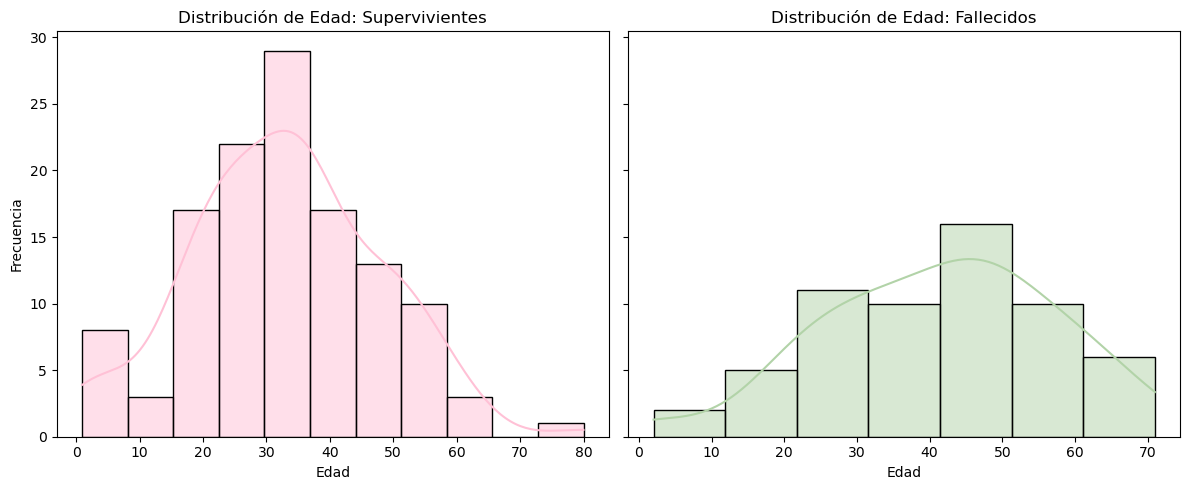

In [39]:
filterSuperviviente = dataFrameL["Survived"] == 1
filterFallecidos = dataFrameL["Survived"] == 0

dataFrameL_Superviviente = dataFrameL[filterSuperviviente]
dataFrameL_Fallecidos = dataFrameL[filterFallecidos]

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.histplot(data=dataFrameL_Superviviente, x="Age", ax=ejes[0], color="#FFC1D6", kde = True)
ejes[0].set_title('Distribución de Edad: Supervivientes')
ejes[0].set_xlabel('Edad')
ejes[0].set_ylabel('Frecuencia')

sns.histplot(data=dataFrameL_Fallecidos, x="Age", ax=ejes[1], color="#B2D3A8", kde = True)
ejes[1].set_title('Distribución de Edad: Fallecidos')
ejes[1].set_xlabel('Edad')

plt.tight_layout()
plt.show()

Entonces, a modo de conclusión de este gráfico, se puede observar que en el caso de los supervivientes se concentró en los menores de ~30 años. En cambio, en el perfil de los fallecidos es mucho más equivalente la edad, aunque los niños registraron un número de fallecimientos menor en comparación al resto, lo cual tiene sentido por las "reglas" con respecto a una emergencia.

### Contraste de Supervivencia por Género

Otro factor importante a considerar podría ser el sexo de la persona y cómo esto afectó a la supervivencia, pues sería interesante revisar si realmente también se cumplen estas "reglas" debido a la emergencia, entonces se realiza el filtro y posteriormente se hace el gráfico.

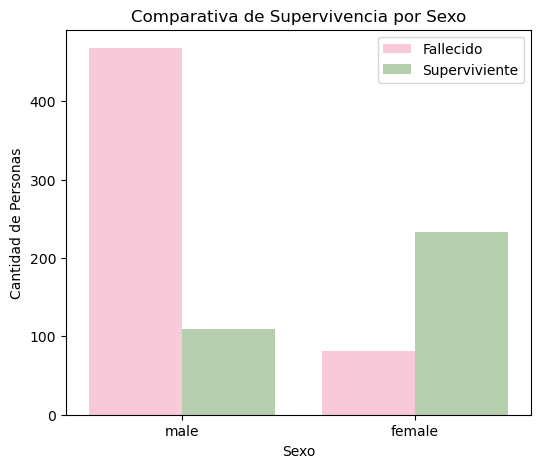

In [50]:
plt.figure(figsize=(6, 5))

sns.countplot(data=dataFrame, x="Sex", hue="Survived", palette={0: "#FFC1D6", 1: "#B2D3A8"})

plt.title('Comparativa de Supervivencia por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Personas')
plt.legend(labels=['Fallecido', 'Superviviente'])

plt.show()

En este caso, como habia comentado, debido a las "reglas" mencionadas las mujeres son las que tienen mayor tasa de supervivencia en comparativo con los hombres. Ahora bien, mirando individualmente cada género:

- En el caso de las <b>mujeres</b>, se observa un sesgo alto entre aquellas que sobrevivieron y las que fallecieron, favoreciendo a la supervivencia.
- En el caso de los <b>hombres</b>, existe un sesgo enorme entre aquellos que fallecieron y quienes sobrevivieron, siendo los que fallecieron muchísimos más.

### Contraste de Supervivencia por Clase

El último caso que me gustaría revisar es la clase social de las personas y cómo esto afectó a su supervivencia. Acá se tienen tres clases principales:

- `1`: Primera Clase.
- `2`: Segunda Clase.
- `3`: Tercera Clase.

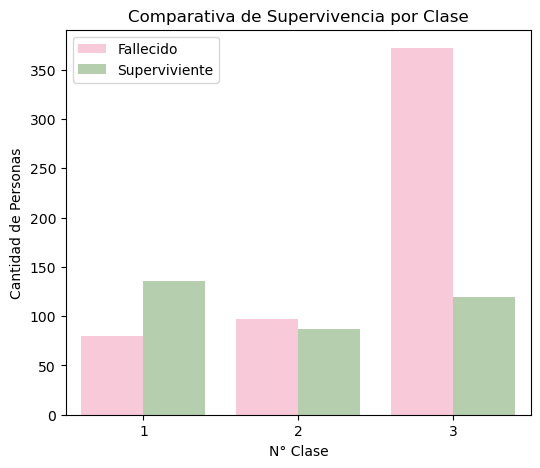

In [49]:
plt.figure(figsize=(6, 5))

sns.countplot(data=dataFrame, x="Pclass", hue="Survived", palette={0: "#FFC1D6", 1: "#B2D3A8"})

plt.title('Comparativa de Supervivencia por Clase')
plt.xlabel('N° Clase')
plt.ylabel('Cantidad de Personas')
plt.legend(labels=['Fallecido', 'Superviviente'])

plt.show()

Al analizar el gráfico, los datos indican que los pasajeros de `Clase 1` experimentaron la mayor tasa de supervivencia y el menor índice de fallecimientos. Por otro lado, la diferencia en la mortalidad de la `Clase 3` es muchísima, lo que en sí, según mi opinión ilustra cómo la clase social influyó directamente en quiénes tuvieron prioridad para salvarse.

### Tasa de Supervivencia Según Número de Familiares

Creo que esto también podría ser importante de visualizar por el hecho de que es interesante saber si el tener familia o no en el viaje afectó a la probabilidad de supervivencia. Para esto, se considera el atributo `Parch`, el cual indica el número de padres/hijos a bordo, y que puede tener valores de entre 0 a 6.

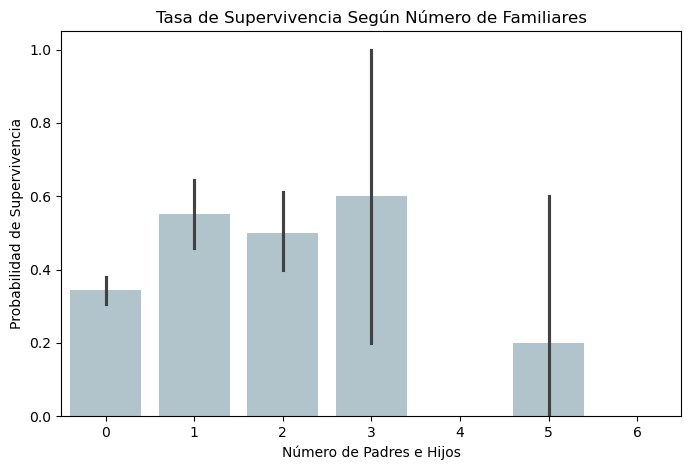

In [60]:
plt.figure(figsize=(8, 5))

sns.barplot(data=dataFrame, x="Parch", y="Survived", color="#AEC6CF")

plt.title('Tasa de Supervivencia Según Número de Familiares')
plt.xlabel('Número de Padres e Hijos')
plt.ylabel('Probabilidad de Supervivencia')

plt.show()

Ahora bien, el gráfico muestra que tener un grupo familiar fue un factor de seguridad hasta cierto punto, porque las familias de gran tamaño (5 personas en este caso), se vieron perjudicadas y se nota en su valor de probabilidad de supervivencia. Lo mismo pasó para aquellos que iban solos, porque también tienen un valor de probabilidad menor a aquellos que tenian entre 1 a 3 familiares.

### Correlación entre Atributos

Por último me gustaría realizar un `heatmap`, para visualizar aquellos atributos que tengan correlación entre ellos.

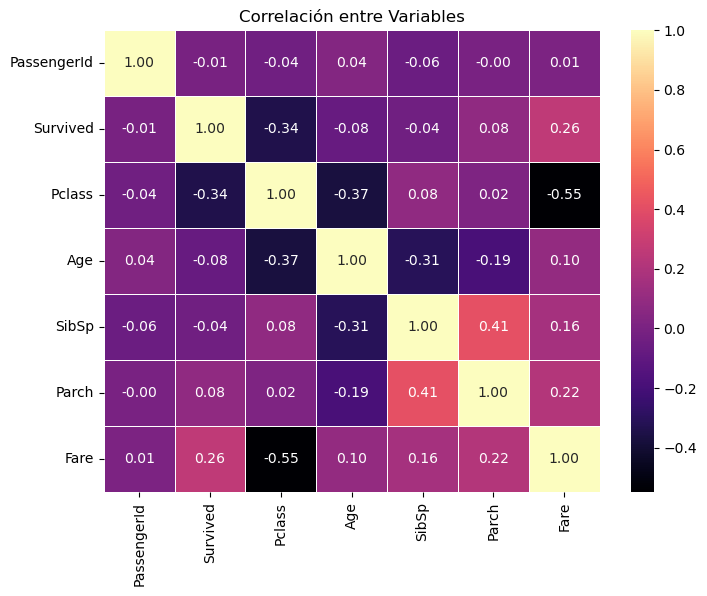

In [81]:
colNumericas = dataFrame.select_dtypes(include=['number'])
correlacion = colNumericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, fmt='.2f', linewidths=0.5, cmap='magma')

plt.title('Correlación entre Variables')
plt.show()

- En este caso, una de las relaciones más importantes sería `Pclass` (clase socioeconómica) con `Fare` (precio del boleto), que tiene un valor de <b>-0.55</b> en el `heatmap`. Acá existe una relación <b>inversamente proporcional</b>, es decir, mientras menor sea el número de clase, mayor es el precio del boleto, lo cual tiene sentido, pues por ejemplo, la primera clase (`1st class`) pagaron el boleto más caro y viceversa con el boleto más barato y la tercera clase (`3rd class`). 

- Ahora, un valor correlativo <b>positivo</b> (si aumenta uno, aumenta el otro) sería el de `SibSp` con `Parch`, con valor <b>0.41</b>, que indican que los pasajeros que viajaban con padres/hijos también tendían a viajar con hermanos/esposos.

## Bibliografía

Acá dejaré algunos de los links que revisé para poder realizar el análisis exploratorio.

- https://www.kaggle.com/code/siddharth0935/exploratory-data-analysis-eda-in-python
- https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/
- https://lauralpezb.medium.com/gu%C3%ADa-practica-para-an%C3%A1lisis-exploratorio-de-datos-con-pandas-565f09a187ab